# RxIQ — Data Preprocessing & Exploratory Data Analysis

**Project:** RxIQ — Pharma Sales Force Effectiveness & Territory Analytics
**Dataset:** Pharmaceutical Company Wholesale-Retail Data (Foresight BI)
**Goal:** Clean the raw sales data and explore rep, territory, channel, and product-level
patterns to surface a headline finding for the territory-optimization analysis.

This notebook covers:
1. Load & inspect raw data
2. Data cleaning & preprocessing
3. Exploratory Data Analysis (EDA)
4. Key findings summary


## 1. Load & Inspect Raw Data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)

df = pd.read_csv("../data/raw/pharma-data.csv")
print(df.shape)
df.head()

(254082, 18)


,Distributor,Customer Name,City,Country,Latitude,Longitude,Channel,Sub-channel,Product Name,Product Class,Quantity,Price,Sales,Month,Year,Name of Sales Rep,Manager,Sales Team
0,Gottlieb-Cruickshank,"Zieme, Doyle and Kunze",Lublin,Poland,51.2333,22.5667,Hospital,Private,Topipizole,Mood Stabilizers,4.0,368,1472.0,January,2018,Mary Gerrard,Britanny Bold,Delta
1,Gottlieb-Cruickshank,Feest PLC,Świecie,Poland,53.4167,18.4333,Pharmacy,Retail,Choriotrisin,Antibiotics,7.0,591,4137.0,January,2018,Jessica Smith,Britanny Bold,Delta
2,Gottlieb-Cruickshank,Medhurst-Beer Pharmaceutical Limited,Rybnik,Poland,50.0833,18.5000,Pharmacy,Institution,Acantaine,Antibiotics,30.0,66,1980.0,January,2018,Steve Pepple,Tracy Banks,Bravo
3,Gottlieb-Cruickshank,Barton Ltd Pharma Plc,Czeladź,Poland,50.3333,19.0833,Hospital,Private,Lioletine Refliruvax,Analgesics,6.0,435,2610.0,January,2018,Mary Gerrard,Britanny Bold,Delta
4,Gottlieb-Cruickshank,Keeling LLC Pharmacy,Olsztyn,Poland,53.7800,20.4942,Pharmacy,Retail,Oxymotroban Fexoformin,Analgesics,20.0,458,9160.0,January,2018,Anne Wu,Britanny Bold,Delta


In [2]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 254082 entries, 0 to 254081
Data columns (total 18 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   Distributor        254082 non-null  str    
 1   Customer Name      254082 non-null  str    
 2   City               254082 non-null  str    
 3   Country            254082 non-null  str    
 4   Latitude           254082 non-null  float64
 5   Longitude          254082 non-null  float64
 6   Channel            254082 non-null  str    
 7   Sub-channel        254082 non-null  str    
 8   Product Name       254082 non-null  str    
 9   Product Class      254082 non-null  str    
 10  Quantity           254082 non-null  float64
 11  Price              254082 non-null  int64  
 12  Sales              254082 non-null  float64
 13  Month              254082 non-null  str    
 14  Year               254082 non-null  int64  
 15  Name of Sales Rep  254082 non-null  str    
 16  Manager      

In [3]:
df.isnull().sum()

Distributor          0
Customer Name        0
City                 0
Country              0
Latitude             0
Longitude            0
Channel              0
Sub-channel          0
Product Name         0
Product Class        0
Quantity             0
Price                0
Sales                0
Month                0
Year                 0
Name of Sales Rep    0
Manager              0
Sales Team           0
dtype: int64

In [4]:
# Check for whitespace issues, duplicates, and invalid values
print("Duplicate rows:", df.duplicated().sum())
print()
print("Sample distributor names (note trailing whitespace):")
print(df['Distributor'].unique()[:5])
print()
print("Rows with Quantity <= 0:", (df['Quantity'] <= 0).sum())
print("Rows with Sales <= 0:", (df['Sales'] <= 0).sum())

Duplicate rows: 4

Sample distributor names (note trailing whitespace):
<StringArray>
['Gottlieb-Cruickshank  ',          'Carter-Conn  ',        'Prohaska-Kuhic ',
             'Smith Inc ',               'Rohan   ']
Length: 5, dtype: str

Rows with Quantity <= 0: 2660
Rows with Sales <= 0: 2660


## 2. Data Cleaning & Preprocessing

Steps:
- Standardize column names (snake_case)
- Strip whitespace from text fields
- Drop exact duplicate rows
- Separate zero-activity rows (Quantity=0 / Sales=0) rather than silently dropping them
- Validate Sales = Price x Quantity
- Fix data types, build a proper `date` column


In [5]:
df_clean = df.copy()

# Standardize column names
df_clean.columns = (
    df_clean.columns.str.strip()
    .str.lower()
    .str.replace(" ", "_")
    .str.replace("-", "_")
)
df_clean = df_clean.rename(columns={"name_of_sales_rep": "sales_rep"})
df_clean.columns.tolist()

['distributor',
 'customer_name',
 'city',
 'country',
 'latitude',
 'longitude',
 'channel',
 'sub_channel',
 'product_name',
 'product_class',
 'quantity',
 'price',
 'sales',
 'month',
 'year',
 'sales_rep',
 'manager',
 'sales_team']

In [6]:
# Strip whitespace from all text columns
str_cols = df_clean.select_dtypes(include="object").columns
for col in str_cols:
    df_clean[col] = df_clean[col].astype(str).str.strip()

df_clean['distributor'].unique()[:5]

/tmp/ipykernel_570/451424270.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  str_cols = df_clean.select_dtypes(include="object").columns


<StringArray>
['Gottlieb-Cruickshank', 'Carter-Conn', 'Prohaska-Kuhic', 'Smith Inc',
 'Rohan']
Length: 5, dtype: str

In [7]:
# Drop duplicates
before = len(df_clean)
df_clean = df_clean.drop_duplicates()
print(f"Dropped {before - len(df_clean)} duplicate rows")

Dropped 4 duplicate rows


In [8]:
# Separate zero-activity rows instead of silently dropping
zero_activity = df_clean[(df_clean['quantity'] <= 0) | (df_clean['sales'] <= 0)]
print(f"Zero-activity rows: {len(zero_activity)} ({len(zero_activity)/len(df_clean):.2%})")

df_clean = df_clean[(df_clean['quantity'] > 0) & (df_clean['sales'] > 0)].copy()
print(f"Remaining rows: {len(df_clean)}")

Zero-activity rows: 2660 (1.05%)
Remaining rows: 251418


In [9]:
# Validate Sales = Price * Quantity
mismatch = (df_clean['sales'] - df_clean['price'] * df_clean['quantity']).abs() > 0.01
print(f"Rows where Sales != Price * Quantity: {mismatch.sum()}")

Rows where Sales != Price * Quantity: 0


In [10]:
# Type fixes + build a date column
df_clean['quantity'] = df_clean['quantity'].astype(int)
df_clean['price'] = df_clean['price'].astype(float)
df_clean['sales'] = df_clean['sales'].astype(float)
df_clean['year'] = df_clean['year'].astype(int)

month_order = ["January","February","March","April","May","June",
               "July","August","September","October","November","December"]
df_clean['month'] = pd.Categorical(df_clean['month'], categories=month_order, ordered=True)
df_clean['month_num'] = df_clean['month'].cat.codes + 1
df_clean['date'] = pd.to_datetime(dict(year=df_clean['year'], month=df_clean['month_num'], day=1))

print(f"Final cleaned shape: {df_clean.shape}")
df_clean.head()

Final cleaned shape: (251418, 20)


,distributor,customer_name,city,country,latitude,longitude,channel,sub_channel,product_name,product_class,quantity,price,sales,month,year,sales_rep,manager,sales_team,month_num,date
0,Gottlieb-Cruickshank,"Zieme, Doyle and Kunze",Lublin,Poland,51.2333,22.5667,Hospital,Private,Topipizole,Mood Stabilizers,4,368.0,1472.0,January,2018,Mary Gerrard,Britanny Bold,Delta,1,2018-01-01
1,Gottlieb-Cruickshank,Feest PLC,Świecie,Poland,53.4167,18.4333,Pharmacy,Retail,Choriotrisin,Antibiotics,7,591.0,4137.0,January,2018,Jessica Smith,Britanny Bold,Delta,1,2018-01-01
2,Gottlieb-Cruickshank,Medhurst-Beer Pharmaceutical Limited,Rybnik,Poland,50.0833,18.5000,Pharmacy,Institution,Acantaine,Antibiotics,30,66.0,1980.0,January,2018,Steve Pepple,Tracy Banks,Bravo,1,2018-01-01
3,Gottlieb-Cruickshank,Barton Ltd Pharma Plc,Czeladź,Poland,50.3333,19.0833,Hospital,Private,Lioletine Refliruvax,Analgesics,6,435.0,2610.0,January,2018,Mary Gerrard,Britanny Bold,Delta,1,2018-01-01
4,Gottlieb-Cruickshank,Keeling LLC Pharmacy,Olsztyn,Poland,53.7800,20.4942,Pharmacy,Retail,Oxymotroban Fexoformin,Analgesics,20,458.0,9160.0,January,2018,Anne Wu,Britanny Bold,Delta,1,2018-01-01


In [11]:
# Save cleaned data (matches data/processed/pharma_clean.csv used in the SQL pipeline)
df_clean.to_csv("../data/processed/pharma_clean.csv", index=False)
print("Saved to data/processed/pharma_clean.csv")

Saved to data/processed/pharma_clean.csv


## 3. Exploratory Data Analysis

### 3.1 Sales Overview

In [12]:
print(f"Total Sales: {df_clean['sales'].sum():,.0f}")
print(f"Total Transactions: {len(df_clean):,}")
print(f"Date Range: {df_clean['date'].min().date()} to {df_clean['date'].max().date()}")
print(f"Countries: {df_clean['country'].unique().tolist()}")
print(f"Sales Reps: {df_clean['sales_rep'].nunique()}")
print(f"Products: {df_clean['product_name'].nunique()}  |  Product Classes: {df_clean['product_class'].nunique()}")

Total Sales: 11,945,457,289
Total Transactions: 251,418
Date Range: 2017-01-01 to 2020-12-01
Countries: ['Poland', 'Germany']
Sales Reps: 13
Products: 240  |  Product Classes: 6


### 3.2 Sales by Country & Channel

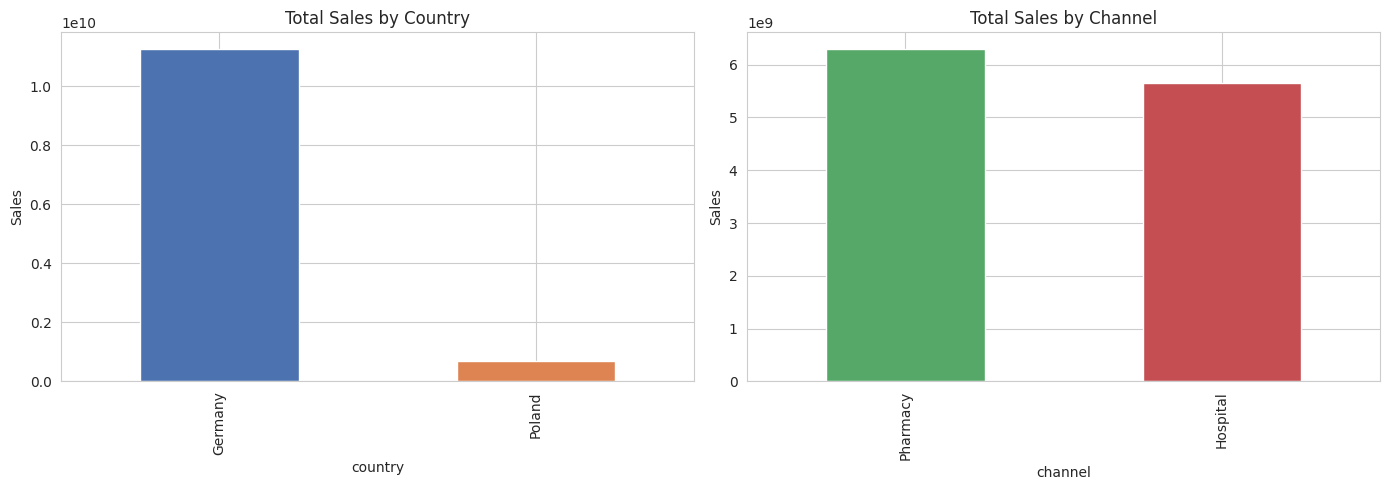

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

country_sales = df_clean.groupby('country')['sales'].sum().sort_values(ascending=False)
country_sales.plot(kind='bar', ax=axes[0], color=['#4C72B0','#DD8452'])
axes[0].set_title('Total Sales by Country')
axes[0].set_ylabel('Sales')

channel_sales = df_clean.groupby('channel')['sales'].sum().sort_values(ascending=False)
channel_sales.plot(kind='bar', ax=axes[1], color=['#55A868','#C44E52'])
axes[1].set_title('Total Sales by Channel')
axes[1].set_ylabel('Sales')

plt.tight_layout()
plt.show()

### 3.3 Sales Rep Performance

In [14]:
rep_sales = df_clean.groupby(['sales_rep','sales_team'])['sales'].sum().sort_values(ascending=False).reset_index()
rep_sales.columns = ['Sales Rep', 'Team', 'Total Sales']
rep_sales

,Sales Rep,Team,Total Sales
0,Jimmy Grey,Charlie,9.949437e+08
1,Abigail Thompson,Bravo,9.903296e+08
2,Sheila Stones,Delta,9.694811e+08
3,Daniel Gates,Charlie,9.655620e+08
4,Anne Wu,Delta,9.297807e+08
5,Morris Garcia,Bravo,9.098420e+08
6,Stella Given,Charlie,8.980462e+08
7,Jessica Smith,Delta,8.935311e+08
8,Steve Pepple,Bravo,8.861836e+08
9,Mary Gerrard,Delta,8.858172e+08


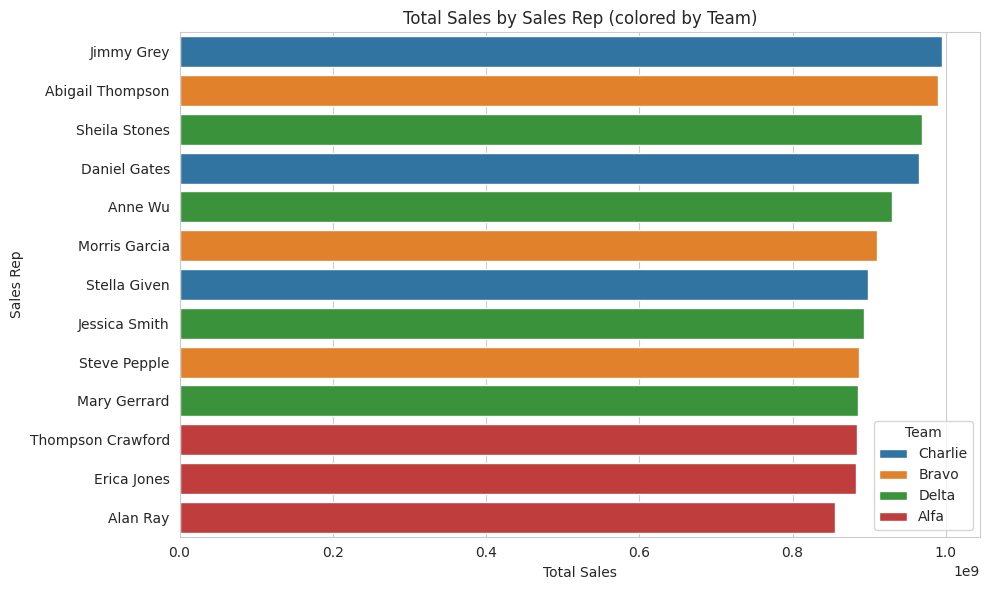

In [15]:
plt.figure(figsize=(10,6))
sns.barplot(data=rep_sales, y='Sales Rep', x='Total Sales', hue='Team', dodge=False)
plt.title('Total Sales by Sales Rep (colored by Team)')
plt.tight_layout()
plt.show()

### 3.4 Sales Team Comparison

In [16]:
team_stats = df_clean.groupby('sales_team').agg(
    total_sales=('sales','sum'),
    avg_deal_size=('sales','mean'),
    num_reps=('sales_rep','nunique'),
    num_transactions=('sales','count')
).sort_values('total_sales', ascending=False)
team_stats

,total_sales,avg_deal_size,num_reps,num_transactions
sales_team,,,,
Delta,3.678610e+09,47500.872762,4,77443
Charlie,2.858552e+09,49385.000096,3,57883
Bravo,2.786355e+09,48019.906987,3,58025
Alfa,2.621940e+09,45153.704107,3,58067


### 3.5 Product Class Breakdown

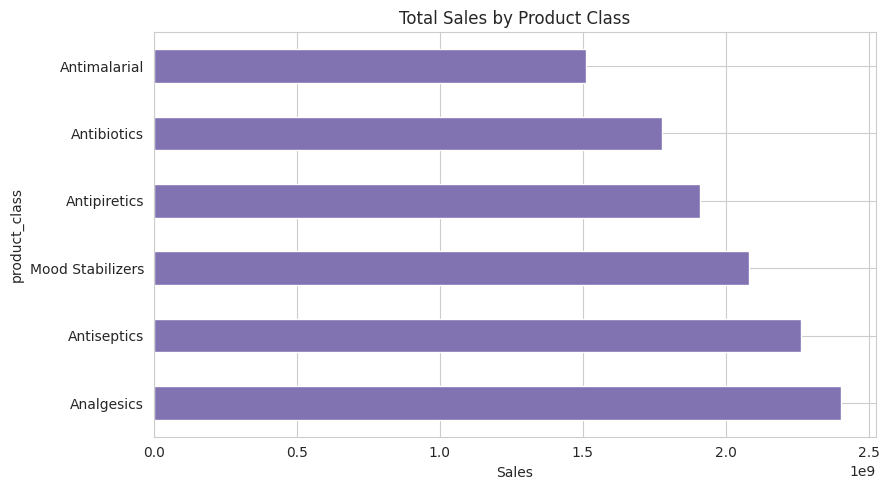

In [17]:
product_class_sales = df_clean.groupby('product_class')['sales'].sum().sort_values(ascending=False)

plt.figure(figsize=(9,5))
product_class_sales.plot(kind='barh', color='#8172B2')
plt.title('Total Sales by Product Class')
plt.xlabel('Sales')
plt.tight_layout()
plt.show()

### 3.6 Monthly Sales Trend

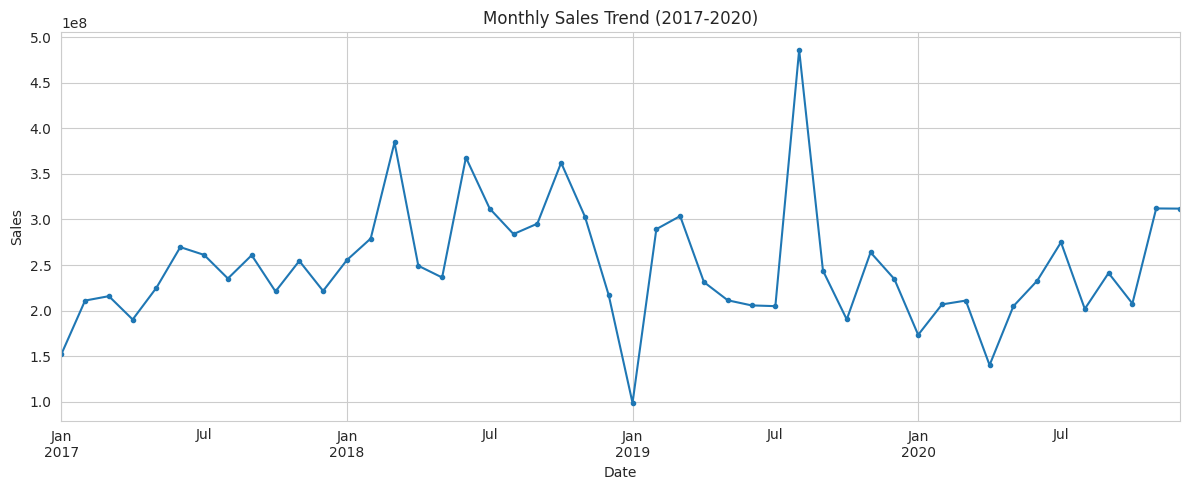

In [18]:
monthly_sales = df_clean.groupby('date')['sales'].sum().sort_index()

plt.figure(figsize=(12,5))
monthly_sales.plot(marker='o', markersize=3)
plt.title('Monthly Sales Trend (2017-2020)')
plt.ylabel('Sales')
plt.xlabel('Date')
plt.tight_layout()
plt.show()

### 3.7 Geographic Coverage — Sales by City (Top 15)

In [19]:
city_sales = df_clean.groupby(['city','country'])['sales'].sum().sort_values(ascending=False).head(15)
city_sales

city            country
Butzbach        Germany    9.496792e+07
Baesweiler      Germany    6.491461e+07
Cuxhaven        Germany    5.639318e+07
Friedberg       Germany    5.231165e+07
Altenburg       Germany    5.098478e+07
Emsdetten       Germany    4.611512e+07
Bottrop         Germany    4.471906e+07
Trier           Germany    4.388614e+07
Freising        Germany    4.385093e+07
Castrop-Rauxel  Germany    4.229353e+07
Limburg         Germany    4.166306e+07
Wedel           Germany    4.088231e+07
Berlin          Germany    4.086481e+07
Ditzingen       Germany    4.048810e+07
Dachau          Germany    3.795763e+07
Name: sales, dtype: float64

### 3.8 Territory Coverage Signal: Reps vs. Cities Covered

In [20]:
rep_coverage = df_clean.groupby('sales_rep').agg(
    cities_covered=('city','nunique'),
    total_sales=('sales','sum'),
    avg_sale_per_city=('sales', lambda x: x.sum())
).reset_index()
rep_coverage['sales_per_city'] = rep_coverage['total_sales'] / rep_coverage['cities_covered']
rep_coverage.sort_values('sales_per_city', ascending=False)

,sales_rep,cities_covered,total_sales,avg_sale_per_city,sales_per_city
6,Jimmy Grey,749,9.949437e+08,9.949437e+08,1.328363e+06
0,Abigail Thompson,749,9.903296e+08,9.903296e+08,1.322202e+06
9,Sheila Stones,749,9.694811e+08,9.694811e+08,1.294367e+06
3,Daniel Gates,749,9.655620e+08,9.655620e+08,1.289135e+06
2,Anne Wu,749,9.297807e+08,9.297807e+08,1.241363e+06
8,Morris Garcia,749,9.098420e+08,9.098420e+08,1.214742e+06
10,Stella Given,749,8.980462e+08,8.980462e+08,1.198994e+06
5,Jessica Smith,749,8.935311e+08,8.935311e+08,1.192965e+06
11,Steve Pepple,749,8.861836e+08,8.861836e+08,1.183156e+06
7,Mary Gerrard,749,8.858172e+08,8.858172e+08,1.182666e+06


## 4. Key Findings Summary

- **Team performance spread:** Delta leads with ~$3.68B total sales (4 reps), while Alfa
  trails at ~$2.62B (3 reps) — roughly a 40% gap between top and bottom team.
- **No exclusive territory assignment:** every sales rep transacts across all 749 cities —
  reps aren't assigned distinct geographic territories in this dataset. This means the
  original "coverage gap" framing (rep A covers fewer cities than rep B) doesn't hold here.
  The real performance signal is **sales-per-city efficiency**: top rep (Jimmy Grey) generates
  ~$1.33M/city vs. bottom rep (Alan Ray) at ~$1.14M/city — a ~16% efficiency gap across reps
  operating in the exact same footprint.
- **Country concentration:** Germany accounts for ~94% of total sales (~$11.26B) vs. Poland
  at ~6% (~$0.68B) — a heavily skewed market that any rep-allocation recommendation needs to
  account for.
- **Product class:** Analgesics is the top-selling class (~$2.40B), Antimalarial the lowest
  (~$1.51B) — a ~59% spread between highest and lowest product classes.

**Revised headline finding for RxIQ:** since reps aren't geographically exclusive, the
sharper story is *rep efficiency, not territory coverage* — "Top-performing reps generate
16% more sales per city than bottom performers despite operating in the identical footprint,
pointing to a training/enablement gap rather than a territory-allocation problem." This is
still a strong, ZS-relevant recommendation (rep effectiveness diagnosis), just reframed from
the original coverage-gap hypothesis.
